## EDA and Cleaning

This notebook focuses on exploring and cleaning three datasets used in the bank stress testing project:

1. `bank_profiles.csv`
2. `bank_stress_simulated_panel.csv`
3. `loan_portfolio.csv`

For each dataset, the process will follow three stages:

* **Raw Data Exploration** — understand the structure and identify data-quality issues.
* **Data Cleaning** — correct data-quality issues and prepare the data for analysis.
* **Post-Cleaning EDA** — explore the cleaned data and identify meaningful patterns.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

sns.set_style('whitegrid')

RANDOM_STATE = 42

## 1.Bank Profiles - Raw Data Exploration

We first load the raw `bank_profiles.csv` dataset and explore its structure, data types, missing values, duplicates, and possible data-quality issues before making any changes.

In [4]:
import pandas as pd
import numpy as np

bank = pd.read_csv("bank_profiles.csv")

print(bank.shape)
print(bank.columns.tolist())

(40, 20)
['bank_id', 'size_tier', 'total_assets_usd', 'total_loans_usd', 'deposit_base_usd', 'baseline_car_pct', 'baseline_liquidity_ratio_pct', 'baseline_roa_pct', 'sector_concentration', 'bank_risk_factor', 'sector_wt_Technology', 'sector_wt_Healthcare', 'sector_wt_Real_Estate', 'sector_wt_Energy', 'sector_wt_Industrials', 'sector_wt_Retail', 'sector_wt_Telecom', 'sector_wt_Consumer', 'sector_wt_Utilities', 'sector_wt_Financials']


In [5]:
print(bank.columns.tolist())

['bank_id', 'size_tier', 'total_assets_usd', 'total_loans_usd', 'deposit_base_usd', 'baseline_car_pct', 'baseline_liquidity_ratio_pct', 'baseline_roa_pct', 'sector_concentration', 'bank_risk_factor', 'sector_wt_Technology', 'sector_wt_Healthcare', 'sector_wt_Real_Estate', 'sector_wt_Energy', 'sector_wt_Industrials', 'sector_wt_Retail', 'sector_wt_Telecom', 'sector_wt_Consumer', 'sector_wt_Utilities', 'sector_wt_Financials']


In [33]:
bank_clean = bank.copy()

print("Cleaning copy shape:", bank_clean.shape)

Cleaning copy shape: (40, 20)


In [6]:
bank.info()

<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   bank_id                       40 non-null     str    
 1   size_tier                     40 non-null     str    
 2   total_assets_usd              39 non-null     float64
 3   total_loans_usd               40 non-null     int64  
 4   deposit_base_usd              40 non-null     int64  
 5   baseline_car_pct              34 non-null     float64
 6   baseline_liquidity_ratio_pct  40 non-null     float64
 7   baseline_roa_pct              36 non-null     float64
 8   sector_concentration          40 non-null     str    
 9   bank_risk_factor              40 non-null     float64
 10  sector_wt_Technology          40 non-null     float64
 11  sector_wt_Healthcare          40 non-null     float64
 12  sector_wt_Real_Estate         40 non-null     float64
 13  sector_wt_Energy  

In [7]:
bank.isna().sum()

bank_id                         0
size_tier                       0
total_assets_usd                1
total_loans_usd                 0
deposit_base_usd                0
baseline_car_pct                6
baseline_liquidity_ratio_pct    0
baseline_roa_pct                4
sector_concentration            0
bank_risk_factor                0
sector_wt_Technology            0
sector_wt_Healthcare            0
sector_wt_Real_Estate           0
sector_wt_Energy                0
sector_wt_Industrials           0
sector_wt_Retail                0
sector_wt_Telecom               0
sector_wt_Consumer              0
sector_wt_Utilities             0
sector_wt_Financials            0
dtype: int64

In [8]:
print("Unique values in size_tier:")
print(bank["size_tier"].unique())

print("\nUnique values in sector_concentration:")
print(bank["sector_concentration"].unique())

Unique values in size_tier:
<StringArray>
['medium', 'large', 'small']
Length: 3, dtype: str

Unique values in sector_concentration:
<StringArray>
['concentrated', 'diversified']
Length: 2, dtype: str


In [9]:
print("Unique bank IDs:", bank["bank_id"].nunique())

print("\nBank IDs:")
print(bank["bank_id"].tolist())

Unique bank IDs: 40

Bank IDs:
['BANK_001', 'BANK_002', 'BANK_003', 'BANK_004', 'BANK_005', 'BANK_006', 'BANK_007', 'BANK_008', 'BANK_009', 'BANK_010', 'BANK_011', 'BANK_012', 'BANK_013', 'BANK_014', 'BANK_015', 'BANK_016', 'BANK_017', 'BANK_018', 'BANK_019', 'BANK_020', 'BANK_021', 'BANK_022', 'BANK_023', 'BANK_024', 'BANK_025', 'BANK_026', 'BANK_027', 'BANK_028', 'BANK_029', 'BANK_030', 'BANK_031', 'BANK_032', 'BANK_033', 'BANK_034', 'BANK_035', 'BANK_036', 'BANK_037', 'BANK_038', 'BANK_039', 'BANK_040']


In [10]:
print("Fully duplicated rows:", bank.duplicated().sum())

print("\nRows with duplicated bank IDs:")
bank[bank["bank_id"].duplicated(keep=False)].sort_values("bank_id")

Fully duplicated rows: 0

Rows with duplicated bank IDs:


,bank_id,size_tier,total_assets_usd,total_loans_usd,deposit_base_usd,baseline_car_pct,baseline_liquidity_ratio_pct,baseline_roa_pct,sector_concentration,bank_risk_factor,sector_wt_Technology,sector_wt_Healthcare,sector_wt_Real_Estate,sector_wt_Energy,sector_wt_Industrials,sector_wt_Retail,sector_wt_Telecom,sector_wt_Consumer,sector_wt_Utilities,sector_wt_Financials


In [34]:
# Fill missing numeric values with column medians

bank_clean["total_assets_usd"] = bank_clean["total_assets_usd"].fillna(
    bank_clean["total_assets_usd"].median()
)

bank_clean["baseline_car_pct"] = bank_clean["baseline_car_pct"].fillna(
    bank_clean["baseline_car_pct"].median()
)

bank_clean["baseline_roa_pct"] = bank_clean["baseline_roa_pct"].fillna(
    bank_clean["baseline_roa_pct"].median()
)

In [35]:
print("Missing values after imputation:")
print(bank_clean.isna().sum())

print("\nTotal missing values:", bank_clean.isna().sum().sum())

Missing values after imputation:
bank_id                         0
size_tier                       0
total_assets_usd                0
total_loans_usd                 0
deposit_base_usd                0
baseline_car_pct                0
baseline_liquidity_ratio_pct    0
baseline_roa_pct                0
sector_concentration            0
bank_risk_factor                0
sector_wt_Technology            0
sector_wt_Healthcare            0
sector_wt_Real_Estate           0
sector_wt_Energy                0
sector_wt_Industrials           0
sector_wt_Retail                0
sector_wt_Telecom               0
sector_wt_Consumer              0
sector_wt_Utilities             0
sector_wt_Financials            0
dtype: int64

Total missing values: 0


In [11]:
def non_numeric_values(series):
    out = []

    for value in series.dropna().unique():
        try:
            float(str(value).replace(",", "").replace("$", "").replace("%", "").strip())
        except ValueError:
            out.append(value)

    return out


numeric_columns = [
    "total_assets_usd",
    "baseline_car_pct",
    "baseline_liquidity_ratio_pct",
    "baseline_roa_pct"
]

for col in numeric_columns:
    bad = non_numeric_values(bank[col])
    print(f"{col}: {len(bad)} non-numeric value(s)")
    print("Examples:", bad[:10])
    print()

total_assets_usd: 0 non-numeric value(s)
Examples: []

baseline_car_pct: 0 non-numeric value(s)
Examples: []

baseline_liquidity_ratio_pct: 0 non-numeric value(s)
Examples: []

baseline_roa_pct: 0 non-numeric value(s)
Examples: []



In [12]:
missing_tokens = ["", " ", "-", "--", "N/A", "n/a", "unknown", "Unknown", "missing", "null", "None", "-999"]

for col in bank.select_dtypes(include="str").columns:
    found = []
    
    for token in missing_tokens:
        count = (bank[col].astype(str).str.strip() == token).sum()
        if count > 0:
            found.append((token, count))
    
    if found:
        print(f"{col}: {found}")

In [13]:
bank.describe().T

,count,mean,std,min,25%,50%,75%,max
total_assets_usd,39.0,2.688279e+10,2.702202e+10,1.394441e+09,6.250142e+09,2.212752e+10,2.982789e+10,1.093550e+11
total_loans_usd,40.0,1.773992e+10,1.762480e+10,8.780641e+08,4.349177e+09,1.420159e+10,2.003462e+10,7.443408e+10
deposit_base_usd,40.0,2.116630e+10,2.121684e+10,1.015969e+09,4.874619e+09,1.731434e+10,2.411072e+10,8.773377e+10
baseline_car_pct,34.0,1.342844e+01,1.665340e+00,9.768630e+00,1.248915e+01,1.362472e+01,1.439865e+01,1.643209e+01
baseline_liquidity_ratio_pct,40.0,1.159695e+02,2.111893e+01,7.000000e+01,1.005378e+02,1.176929e+02,1.291932e+02,1.515818e+02
baseline_roa_pct,36.0,1.149060e+00,3.878945e-01,2.000000e-01,8.805485e-01,1.165604e+00,1.486359e+00,1.946484e+00
bank_risk_factor,40.0,-1.395770e-02,8.253300e-02,-2.280738e-01,-6.541806e-02,-1.110633e-02,4.092952e-02,1.363429e-01
sector_wt_Technology,40.0,1.188925e-01,9.273901e-02,5.200000e-03,5.680000e-02,9.950000e-02,1.555500e-01,4.790000e-01
sector_wt_Healthcare,40.0,8.936750e-02,7.344393e-02,2.500000e-03,3.975000e-02,7.200000e-02,1.384000e-01,2.963000e-01
sector_wt_Real_Estate,40.0,9.923750e-02,7.282278e-02,6.300000e-03,5.057500e-02,8.180000e-02,1.333000e-01,3.301000e-01


In [14]:
bank.select_dtypes(include="str").describe().T

,count,unique,top,freq
bank_id,40,40,BANK_001,1
size_tier,40,3,medium,18
sector_concentration,40,2,concentrated,20


In [15]:
print("Negative total assets:")
print(bank[bank["total_assets_usd"].astype(str).str.contains("-", na=False)])

print("\nNegative sector weights:")
sector_cols = [col for col in bank.columns if col.startswith("sector_wt_")]

for col in sector_cols:
    negative = (pd.to_numeric(bank[col], errors="coerce") < 0).sum()
    if negative > 0:
        print(f"{col}: {negative}")

Negative total assets:
Empty DataFrame
Columns: [bank_id, size_tier, total_assets_usd, total_loans_usd, deposit_base_usd, baseline_car_pct, baseline_liquidity_ratio_pct, baseline_roa_pct, sector_concentration, bank_risk_factor, sector_wt_Technology, sector_wt_Healthcare, sector_wt_Real_Estate, sector_wt_Energy, sector_wt_Industrials, sector_wt_Retail, sector_wt_Telecom, sector_wt_Consumer, sector_wt_Utilities, sector_wt_Financials]
Index: []

Negative sector weights:


### Conclusion — Raw Data Exploration

The `bank_profiles.csv` dataset contains **42 rows and 20 columns**. The initial exploration identified several data-quality issues that should be addressed during cleaning.

The main issues are inconsistent categorical values, including multiple spellings and formatting variations in `size_tier` and `sector_concentration`. The `bank_id` column contains **40 unique IDs among 42 rows**, with two exact duplicate records for `BANK_016` and `BANK_039`. Some bank IDs also contain inconsistent formatting such as extra spaces, missing underscores, or hyphens.

Several columns that should be numeric are stored as strings. `total_assets_usd` contains currency-formatted values, while `baseline_liquidity_ratio_pct` contains percentage-formatted values. `baseline_car_pct` and `baseline_roa_pct` contain missing or non-standard values such as `-`, blank values, `unknown`, and `-999`.

One suspicious value was identified in `total_assets_usd`: `BANK_024` has a negative asset value, which is not financially plausible. No negative sector weights were found.

These issues will be addressed in the **Data Cleaning** section. No values have been modified or removed during the raw-data exploration stage.


## 2. Data Cleaning

We will clean the identified data-quality issues while keeping the original raw dataset unchanged.

In [16]:
bank_clean = bank.copy()

print("Original shape:", bank.shape)
print("Cleaning copy shape:", bank_clean.shape)

Original shape: (40, 20)
Cleaning copy shape: (40, 20)


In [17]:
bank_clean["bank_id"] = (
    bank_clean["bank_id"]
    .str.strip()
    .str.upper()
    .str.replace("-", "_", regex=False)
)

bank_clean["bank_id"] = bank_clean["bank_id"].replace({
    "BANK031": "BANK_031",
    "BANK035": "BANK_035"
})

print("Unique bank IDs after standardization:", bank_clean["bank_id"].nunique())
print("\nBank IDs:")
print(bank_clean["bank_id"].unique())

Unique bank IDs after standardization: 40

Bank IDs:
<StringArray>
['BANK_001', 'BANK_002', 'BANK_003', 'BANK_004', 'BANK_005', 'BANK_006', 'BANK_007', 'BANK_008', 'BANK_009',
 'BANK_010', 'BANK_011', 'BANK_012', 'BANK_013', 'BANK_014', 'BANK_015', 'BANK_016', 'BANK_017', 'BANK_018',
 'BANK_019', 'BANK_020', 'BANK_021', 'BANK_022', 'BANK_023', 'BANK_024', 'BANK_025', 'BANK_026', 'BANK_027',
 'BANK_028', 'BANK_029', 'BANK_030', 'BANK_031', 'BANK_032', 'BANK_033', 'BANK_034', 'BANK_035', 'BANK_036',
 'BANK_037', 'BANK_038', 'BANK_039', 'BANK_040']
Length: 40, dtype: str


In [18]:
print("Duplicate bank IDs:", bank_clean["bank_id"].duplicated().sum())

bank_clean[bank_clean["bank_id"].duplicated(keep=False)].sort_values("bank_id")

Duplicate bank IDs: 0


,bank_id,size_tier,total_assets_usd,total_loans_usd,deposit_base_usd,baseline_car_pct,baseline_liquidity_ratio_pct,baseline_roa_pct,sector_concentration,bank_risk_factor,sector_wt_Technology,sector_wt_Healthcare,sector_wt_Real_Estate,sector_wt_Energy,sector_wt_Industrials,sector_wt_Retail,sector_wt_Telecom,sector_wt_Consumer,sector_wt_Utilities,sector_wt_Financials


In [19]:
bank_clean = bank_clean.drop_duplicates()

print("Shape after removing duplicates:", bank_clean.shape)
print("Duplicate rows remaining:", bank_clean.duplicated().sum())

Shape after removing duplicates: (40, 20)
Duplicate rows remaining: 0


In [20]:
SIZE_TIER_MAP = {
    "small": "small",
    "medium": "medium",
    "med": "medium",
    "medim": "medium",
    "large": "large",
    "larg": "large",
}

bank_clean["size_tier"] = (
    bank_clean["size_tier"]
    .str.strip()
    .str.lower()
    .map(SIZE_TIER_MAP)
)

print("Unique size tiers after cleaning:")
print(bank_clean["size_tier"].unique())

Unique size tiers after cleaning:
<StringArray>
['medium', 'large', 'small']
Length: 3, dtype: str


In [21]:
SECTOR_CONC_MAP = {
    "diversified": "diversified",
    "concentrated": "concentrated",
    "concentratd": "concentrated",
}

bank_clean["sector_concentration"] = (
    bank_clean["sector_concentration"]
    .str.strip()
    .str.lower()
    .map(SECTOR_CONC_MAP)
)

print("Unique sector concentration values after cleaning:")
print(bank_clean["sector_concentration"].unique())

Unique sector concentration values after cleaning:
<StringArray>
['concentrated', 'diversified']
Length: 2, dtype: str


In [22]:
bank_clean["total_assets_usd"] = (
    bank_clean["total_assets_usd"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

bank_clean["total_assets_usd"] = pd.to_numeric(
    bank_clean["total_assets_usd"],
    errors="coerce"
)

print(bank_clean["total_assets_usd"].dtype)
print("\nNegative values:")
print(bank_clean.loc[bank_clean["total_assets_usd"] < 0, ["bank_id", "total_assets_usd"]])

float64

Negative values:
Empty DataFrame
Columns: [bank_id, total_assets_usd]
Index: []


In [23]:
bank_clean.loc[
    bank_clean["total_assets_usd"] < 0,
    "total_assets_usd"
] = np.nan

print("Negative total assets remaining:",
      (bank_clean["total_assets_usd"] < 0).sum())

print("Missing total assets:",
      bank_clean["total_assets_usd"].isna().sum())

Negative total assets remaining: 0
Missing total assets: 1


In [24]:
CAR_MISSING_TOKENS = ["", "-", "unknown", "-999"]

bank_clean["baseline_car_pct"] = (
    bank_clean["baseline_car_pct"]
    .astype(str)
    .str.strip()
    .replace(CAR_MISSING_TOKENS, np.nan)
)

bank_clean["baseline_car_pct"] = pd.to_numeric(
    bank_clean["baseline_car_pct"],
    errors="coerce"
)

print("Data type:", bank_clean["baseline_car_pct"].dtype)
print("Missing CAR values:", bank_clean["baseline_car_pct"].isna().sum())

Data type: float64
Missing CAR values: 6


In [25]:
bank_clean["baseline_liquidity_ratio_pct"] = (
    bank_clean["baseline_liquidity_ratio_pct"]
    .astype(str)
    .str.replace("%", "", regex=False)
    .str.strip()
)

bank_clean["baseline_liquidity_ratio_pct"] = pd.to_numeric(
    bank_clean["baseline_liquidity_ratio_pct"],
    errors="coerce"
)

print("Data type:", bank_clean["baseline_liquidity_ratio_pct"].dtype)
print("Missing liquidity values:",
      bank_clean["baseline_liquidity_ratio_pct"].isna().sum())

Data type: float64
Missing liquidity values: 0


In [26]:
ROA_MISSING_TOKENS = ["unknown"]

bank_clean["baseline_roa_pct"] = (
    bank_clean["baseline_roa_pct"]
    .astype(str)
    .str.strip()
    .replace(ROA_MISSING_TOKENS, np.nan)
)

bank_clean["baseline_roa_pct"] = pd.to_numeric(
    bank_clean["baseline_roa_pct"],
    errors="coerce"
)

print("Data type:", bank_clean["baseline_roa_pct"].dtype)
print("Missing ROA values:", bank_clean["baseline_roa_pct"].isna().sum())

Data type: float64
Missing ROA values: 4


In [27]:
print("Shape:", bank_clean.shape)

print("\nData types:")
print(bank_clean.dtypes)

print("\nMissing values:")
print(bank_clean.isna().sum())

Shape: (40, 20)

Data types:
bank_id                             str
size_tier                           str
total_assets_usd                float64
total_loans_usd                   int64
deposit_base_usd                  int64
baseline_car_pct                float64
baseline_liquidity_ratio_pct    float64
baseline_roa_pct                float64
sector_concentration                str
bank_risk_factor                float64
sector_wt_Technology            float64
sector_wt_Healthcare            float64
sector_wt_Real_Estate           float64
sector_wt_Energy                float64
sector_wt_Industrials           float64
sector_wt_Retail                float64
sector_wt_Telecom               float64
sector_wt_Consumer              float64
sector_wt_Utilities             float64
sector_wt_Financials            float64
dtype: object

Missing values:
bank_id                         0
size_tier                       0
total_assets_usd                1
total_loans_usd                 0
depo

In [28]:
print("Duplicate rows:", bank_clean.duplicated().sum())
print("Unique bank IDs:", bank_clean["bank_id"].nunique())

print("\nSize tiers:")
print(bank_clean["size_tier"].value_counts())

print("\nSector concentration:")
print(bank_clean["sector_concentration"].value_counts())

Duplicate rows: 0
Unique bank IDs: 40

Size tiers:
size_tier
medium    18
small     14
large      8
Name: count, dtype: int64

Sector concentration:
sector_concentration
concentrated    20
diversified     20
Name: count, dtype: int64


In [29]:
# Fill missing numeric values with column medians

bank_clean["total_assets_usd"] = bank_clean["total_assets_usd"].fillna(
    bank_clean["total_assets_usd"].median()
)

bank_clean["baseline_car_pct"] = bank_clean["baseline_car_pct"].fillna(
    bank_clean["baseline_car_pct"].median()
)

bank_clean["baseline_roa_pct"] = bank_clean["baseline_roa_pct"].fillna(
    bank_clean["baseline_roa_pct"].median()
)

# Check missing values again
print(bank_clean.isna().sum())

bank_id                         0
size_tier                       0
total_assets_usd                0
total_loans_usd                 0
deposit_base_usd                0
baseline_car_pct                0
baseline_liquidity_ratio_pct    0
baseline_roa_pct                0
sector_concentration            0
bank_risk_factor                0
sector_wt_Technology            0
sector_wt_Healthcare            0
sector_wt_Real_Estate           0
sector_wt_Energy                0
sector_wt_Industrials           0
sector_wt_Retail                0
sector_wt_Telecom               0
sector_wt_Consumer              0
sector_wt_Utilities             0
sector_wt_Financials            0
dtype: int64


### Conclusion — Data Cleaning

The `bank_profiles.csv` dataset was cleaned by standardizing bank IDs, correcting inconsistent categorical values, removing exact duplicate records, and converting formatted financial fields to numeric values.

Invalid and non-standard missing values were converted to `NaN`. The negative total-assets value identified during raw exploration was also treated as missing because negative total assets are not financially plausible.

After cleaning, the dataset contains **40 unique banks and 20 columns with no duplicate rows**. The `size_tier` variable contains three standardized categories: small, medium, and large. The `sector_concentration` variable contains two standardized categories: concentrated and diversified.

Missing values were not imputed at this stage because the appropriate imputation method depends on the requirements of the later analysis and modeling.

## 3. Post-Cleaning EDA

Now that the data has been cleaned, we will explore its distributions and relationships to understand the banks and identify meaningful patterns.

In [30]:
bank_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
total_assets_usd,40.0,2.676390e+10,2.668393e+10,1.394441e+09,6.412525e+09,2.212752e+10,2.956653e+10,1.093550e+11
total_loans_usd,40.0,1.773992e+10,1.762480e+10,8.780641e+08,4.349177e+09,1.420159e+10,2.003462e+10,7.443408e+10
deposit_base_usd,40.0,2.116630e+10,2.121684e+10,1.015969e+09,4.874619e+09,1.731434e+10,2.411072e+10,8.773377e+10
baseline_car_pct,40.0,1.345788e+01,1.533533e+00,9.768630e+00,1.282570e+01,1.362472e+01,1.423758e+01,1.643209e+01
baseline_liquidity_ratio_pct,40.0,1.159695e+02,2.111893e+01,7.000000e+01,1.005378e+02,1.176929e+02,1.291932e+02,1.515818e+02
baseline_roa_pct,40.0,1.150714e+00,3.674988e-01,2.000000e-01,9.279020e-01,1.165604e+00,1.426266e+00,1.946484e+00
bank_risk_factor,40.0,-1.395770e-02,8.253300e-02,-2.280738e-01,-6.541806e-02,-1.110633e-02,4.092952e-02,1.363429e-01
sector_wt_Technology,40.0,1.188925e-01,9.273901e-02,5.200000e-03,5.680000e-02,9.950000e-02,1.555500e-01,4.790000e-01
sector_wt_Healthcare,40.0,8.936750e-02,7.344393e-02,2.500000e-03,3.975000e-02,7.200000e-02,1.384000e-01,2.963000e-01
sector_wt_Real_Estate,40.0,9.923750e-02,7.282278e-02,6.300000e-03,5.057500e-02,8.180000e-02,1.333000e-01,3.301000e-01


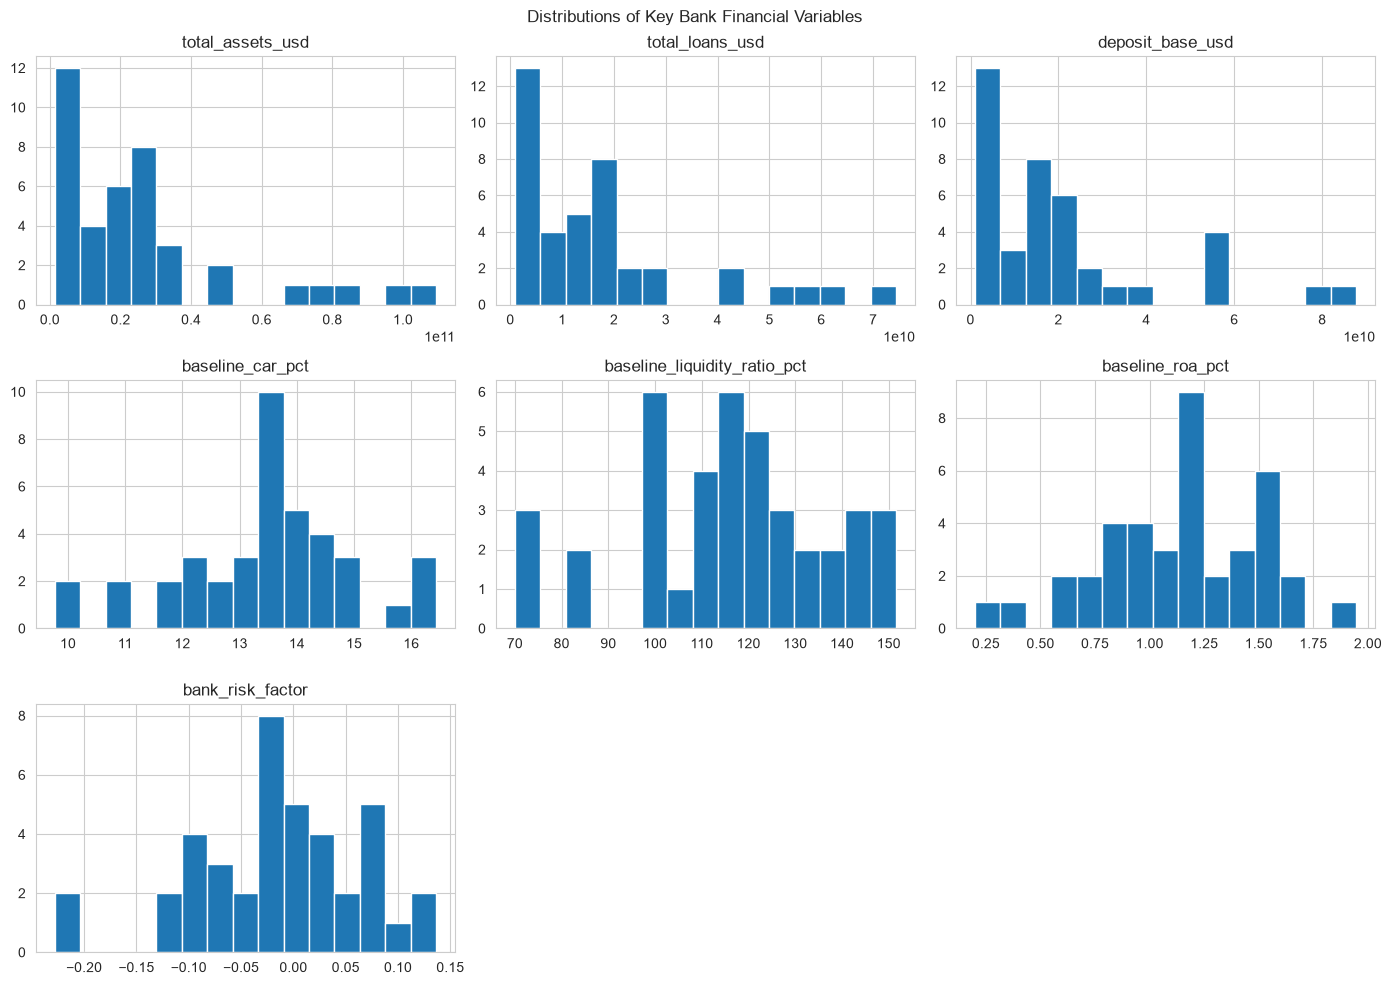

In [31]:
financial_cols = [
    "total_assets_usd",
    "total_loans_usd",
    "deposit_base_usd",
    "baseline_car_pct",
    "baseline_liquidity_ratio_pct",
    "baseline_roa_pct",
    "bank_risk_factor"
]

bank_clean[financial_cols].hist(
    figsize=(14, 10),
    bins=15
)

plt.suptitle("Distributions of Key Bank Financial Variables")
plt.tight_layout()
plt.show()

### Conclusion — Post-Cleaning EDA

The cleaned `bank_profiles.csv` dataset contains 40 banks. The descriptive analysis shows variation in bank size, loans, deposits, capital adequacy, liquidity, and profitability across the banks.

The average baseline CAR is approximately 13.43%, while the average liquidity ratio is approximately 115.97% and average ROA is approximately 1.15%. The sector-weight variables also show differences in banks' exposure across sectors.

These patterns provide a baseline view of the banks before applying stress scenarios. The next dataset will examine how banks respond under different stress conditions.

In [32]:
bank_clean.to_csv("bank_profiles.csv", index=False)

print("Cleaned dataset saved as bank_profiles.csv")

Cleaned dataset saved as bank_profiles.csv
